## sklearn.preprocessing

sklearn.preprocessing is a module in Scikit-Learn that transforms raw data into a format that machine learning algorithms can understand more effectively.

Real-world data often contains:

1-Different feature scales

2-Missing values

3-Categorical variables

4-Outliers

5-Skewed distributions

6-Text labels

Preprocessing converts this raw data into machine-learning-ready data.

Instead of trying to memorize every function, it is much better to organize them into categories:

1-Feature Scaling

2-Encoding features

3-Feature Transformation

4-Discretization (Binning)

5-Polynomial Features 

6-Missing Value Handling

7-Label Processing

8-Custom Transformations

## Categories of Preprocessing Methods

## 1.Feature Scaling

Feature Scaling is a data preprocessing technique used to transform the values of features or variables in a dataset to a similar scale.

The purpose is to ensure that all features contribute equally to the model and to avoid domination of features with larger values.


Note: Used for numerical features.

1-StandardScaler

2-MinMaxScaler

3-RobustScaler

4-MaxAbsScaler

5-Normalizer

## Dataset Used Throughout


In [84]:
import pandas as pd

df = pd.DataFrame({
    "Age":[20,25,30,35,40],
    "Salary":[25000,35000,50000,75000,120000],
    "Experience":[1,2,5,8,15],
    'Rich':[0,0,0,1,1]
})

X=df.drop('Rich',axis=1)
y=df['Rich']
print(df)

   Age  Salary  Experience  Rich
0   20   25000           1     0
1   25   35000           2     0
2   30   50000           5     0
3   35   75000           8     1
4   40  120000          15     1


Why do we need it?

Suppose:

Age      : 20 to 40

Salary   : 25,000 to 120,000

Without scaling:

Salary dominates distance calculations.

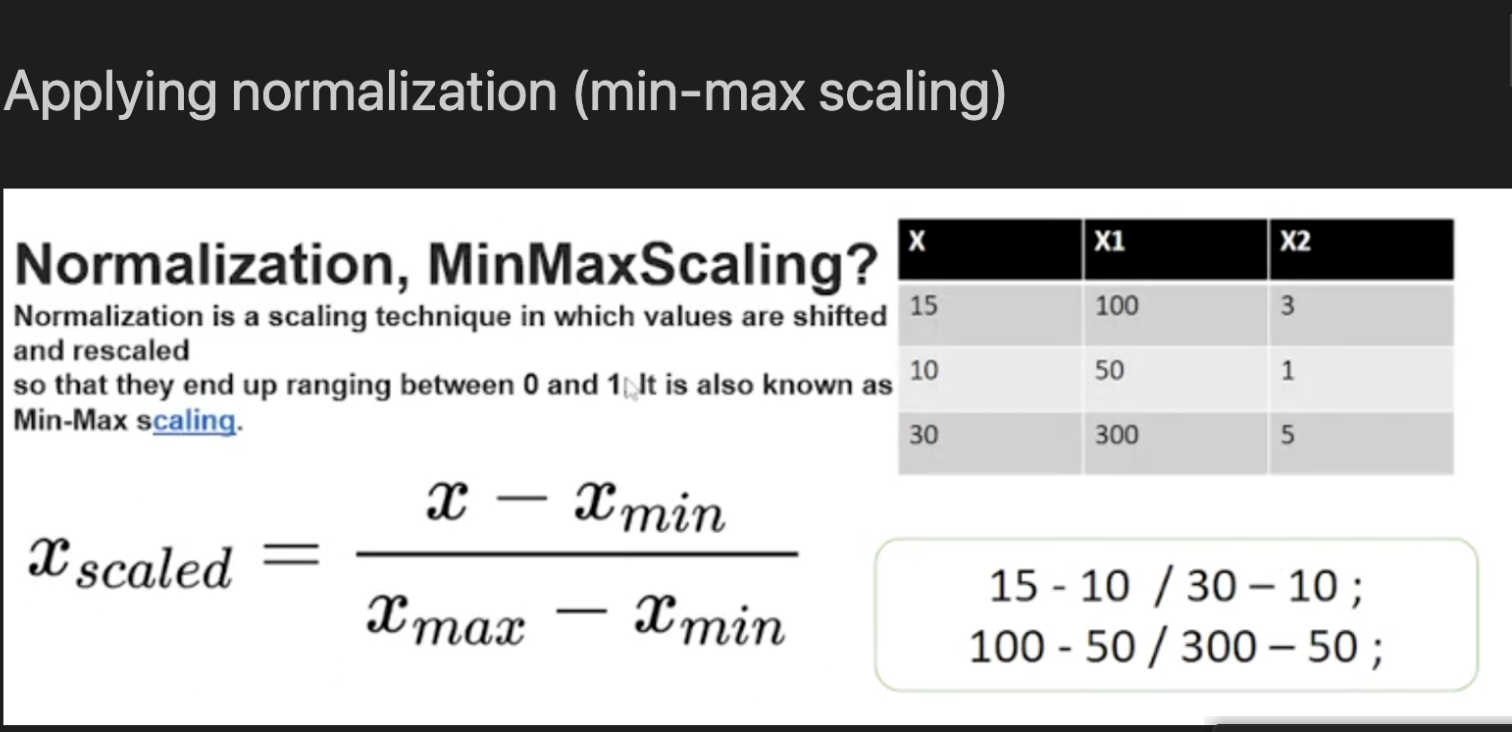

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create scaler
scaler=MinMaxScaler()

# Learn parameters from training data -> learn Xmax and Xmin and scales the data
X_train_scaled = scaler.fit_transform(X_train)

# Apply same parameters to test data (Xmax and Xmin from training data for that column)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled)
print('\n')
print(X_test_scaled)

[[1.         1.         1.        ]
 [0.5        0.26315789 0.28571429]
 [0.         0.         0.        ]
 [0.75       0.52631579 0.5       ]]


[[0.25       0.10526316 0.07142857]]


In [49]:
# What does fit() do?
# scaler.fit(df) Learns:

# scaler.data_min_    min feature value
# scaler.data_max_    max feature value 
# scaler.data_range_  range of each feature in an array
# scaler.n_features_in_  no of features ( 3 here)


In [50]:
scaler.data_range_

array([2.0e+01, 9.5e+04, 1.4e+01])

In [51]:
scaler.data_max_

array([4.0e+01, 1.2e+05, 1.5e+01])

In [52]:
scaler.data_min_

array([2.0e+01, 2.5e+04, 1.0e+00])

In [53]:
# What does transform() do?

# Uses previously learned statistics.

# scaled = scaler.transform(df)



#fit_transform()

# Combination of:

# fit()
# transform() -> fits and transforms at the same time 

## Note : Never use scaler.fit_transform(X_test) . It is wrong 


## Inverse Transformation

In [82]:
original=scaler.inverse_transform(X_train_scaled)
original

array([[4.0e+01, 1.2e+05, 1.5e+01],
       [3.0e+01, 5.0e+04, 5.0e+00],
       [2.0e+01, 2.5e+04, 1.0e+00],
       [3.5e+01, 7.5e+04, 8.0e+00]])

## Interview Question
Why do we use transform() on test data instead of fit_transform()?

Because the preprocessing parameters (mean, standard deviation, minimum, maximum, median, etc.) must be learned only from the training data. Using fit_transform() on test data introduces information from the test set into the model pipeline, causing data leakage and invalid evaluation results.

## What happens if test data exceeds training maximum?

Values can exceed 1.

Example:

train max = 100

test value = 120

scaled value > 1

Best For:

Neural Networks

CNN

Deep Learning

Image Processing

## Interview Questions: 
Why is MinMaxScaler preferred for Neural Networks?

Because activation functions such as sigmoid and tanh perform better with bounded inputs.

In [54]:
X_train_scaled=pd.DataFrame(data=X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(data=X_test_scaled,columns=X_test.columns)

X_train_scaled

,Age,Salary,Experience
0,1.00,1.000000,1.000000
1,0.50,0.263158,0.285714
2,0.00,0.000000,0.000000
3,0.75,0.526316,0.500000


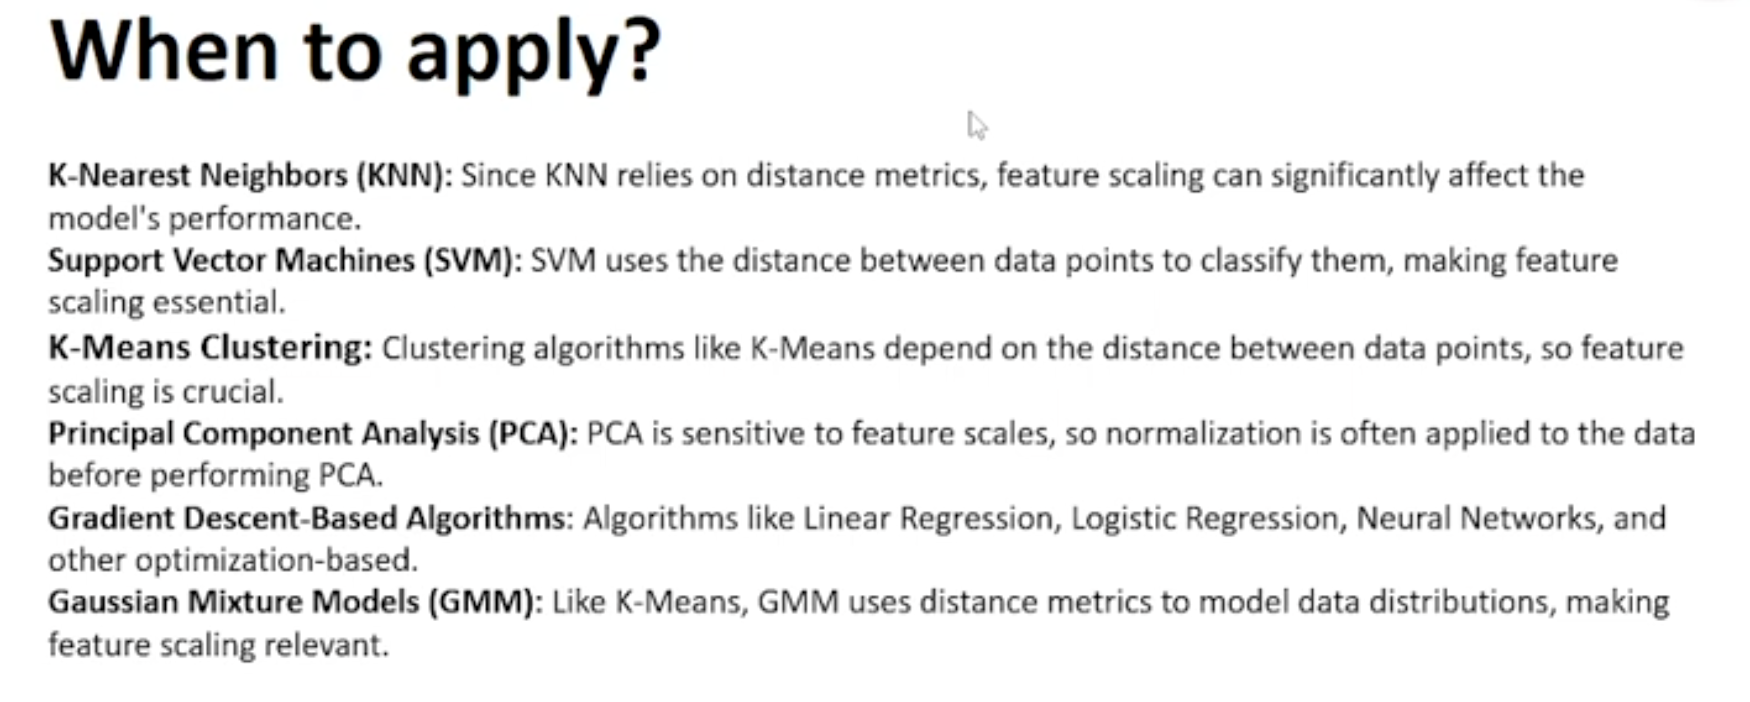

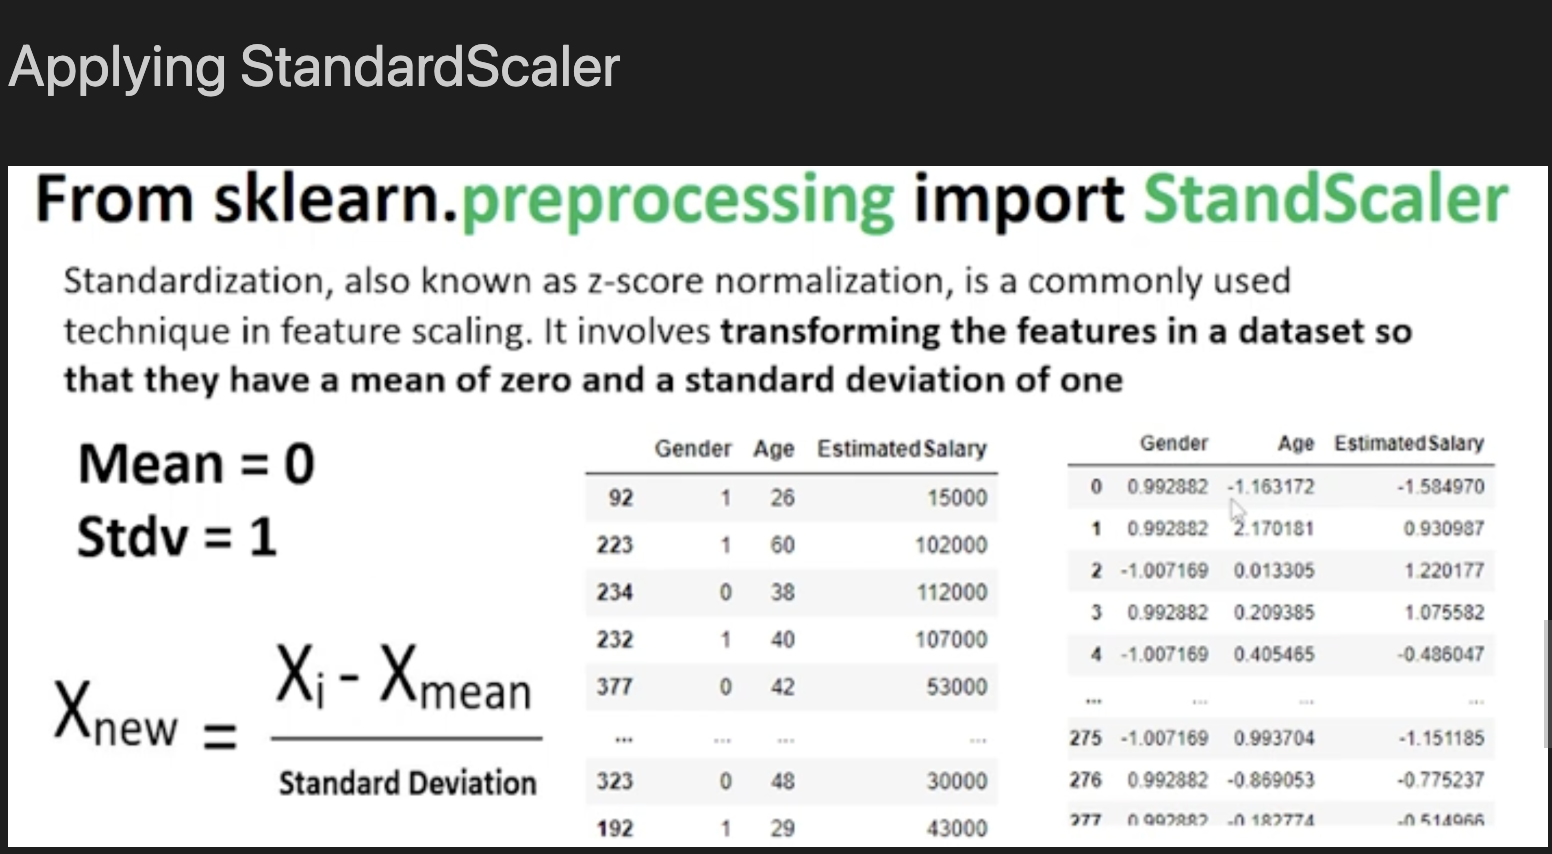

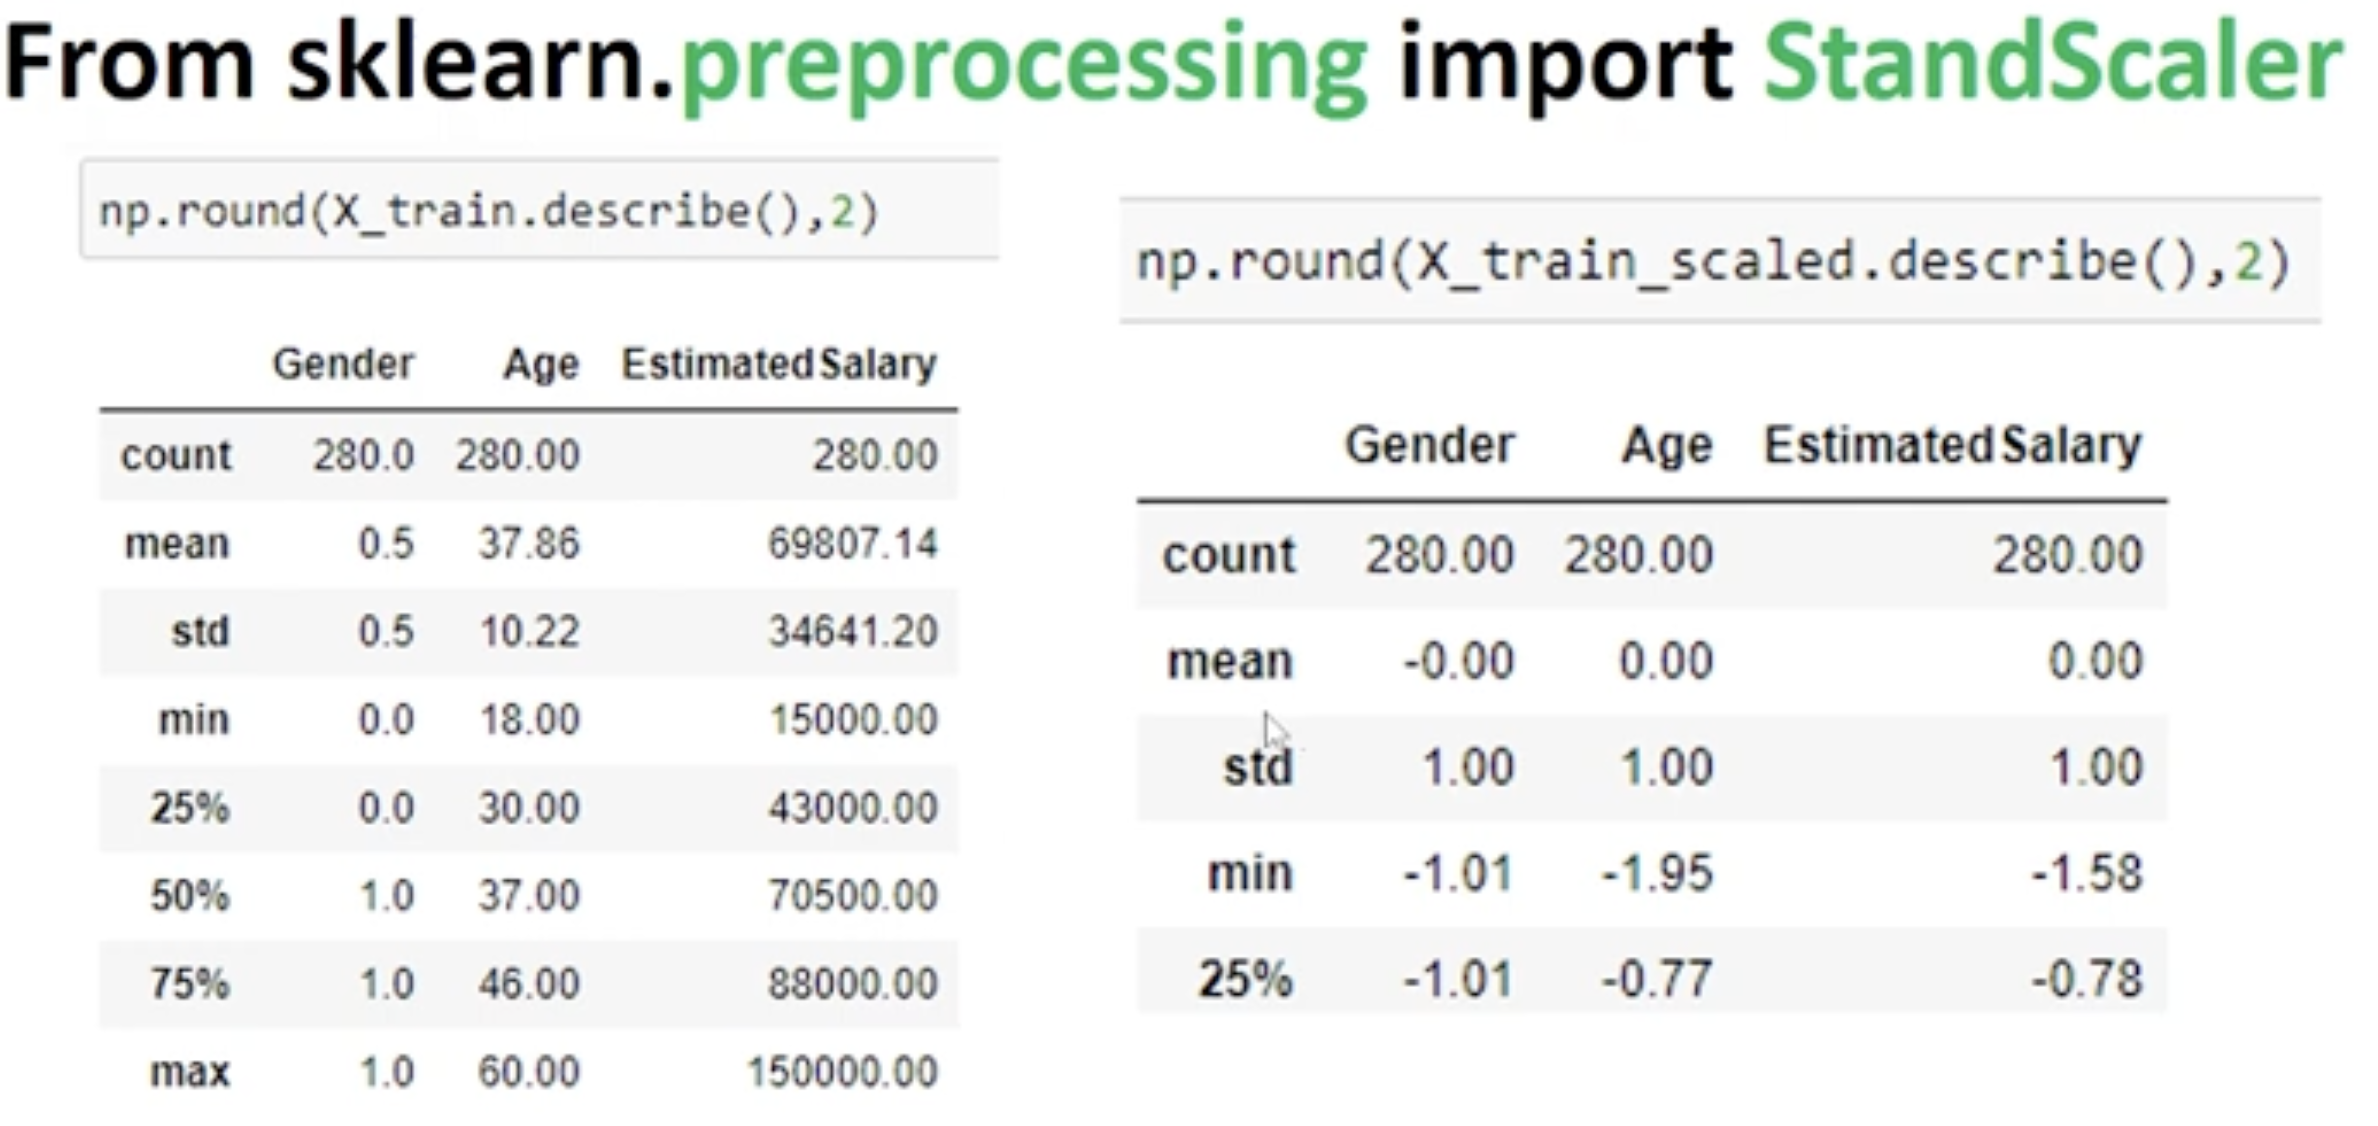

In [55]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
# Learn parameters from training data -> learns Xmean, Xstd , Xvar, Xscale
X_train_scaled = scaler.fit_transform(X_train)

# Apply same parameters to test data (Xstd and Xmean from training data for that column)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled)
print('\n')
print(X_test_scaled)
X_train_scaled=pd.DataFrame(data=X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(data=X_test_scaled,columns=X_test.columns)
print()
print(X_train_scaled)


[[ 1.18321596  1.49618805  1.5144491 ]
 [-0.16903085 -0.49872935 -0.43967877]
 [-1.52127766 -1.21119985 -1.22132992]
 [ 0.50709255  0.21374115  0.14655959]]


[[-0.84515425 -0.92621165 -1.02591713]]

        Age    Salary  Experience
0  1.183216  1.496188    1.514449
1 -0.169031 -0.498729   -0.439679
2 -1.521278 -1.211200   -1.221330
3  0.507093  0.213741    0.146560


In [56]:
import numpy as np
print(np.round(X_train.describe(),2))

         Age     Salary  Experience
count   4.00       4.00        4.00
mean   31.25   67500.00        7.25
std     8.54   40517.49        5.91
min    20.00   25000.00        1.00
25%    27.50   43750.00        4.00
50%    32.50   62500.00        6.50
75%    36.25   86250.00        9.75
max    40.00  120000.00       15.00


In [57]:
print(np.round(X_train_scaled.describe(),2))

        Age  Salary  Experience
count  4.00    4.00        4.00
mean   0.00   -0.00       -0.00
std    1.15    1.15        1.15
min   -1.52   -1.21       -1.22
25%   -0.51   -0.68       -0.64
50%    0.17   -0.14       -0.15
75%    0.68    0.53        0.49
max    1.18    1.50        1.51


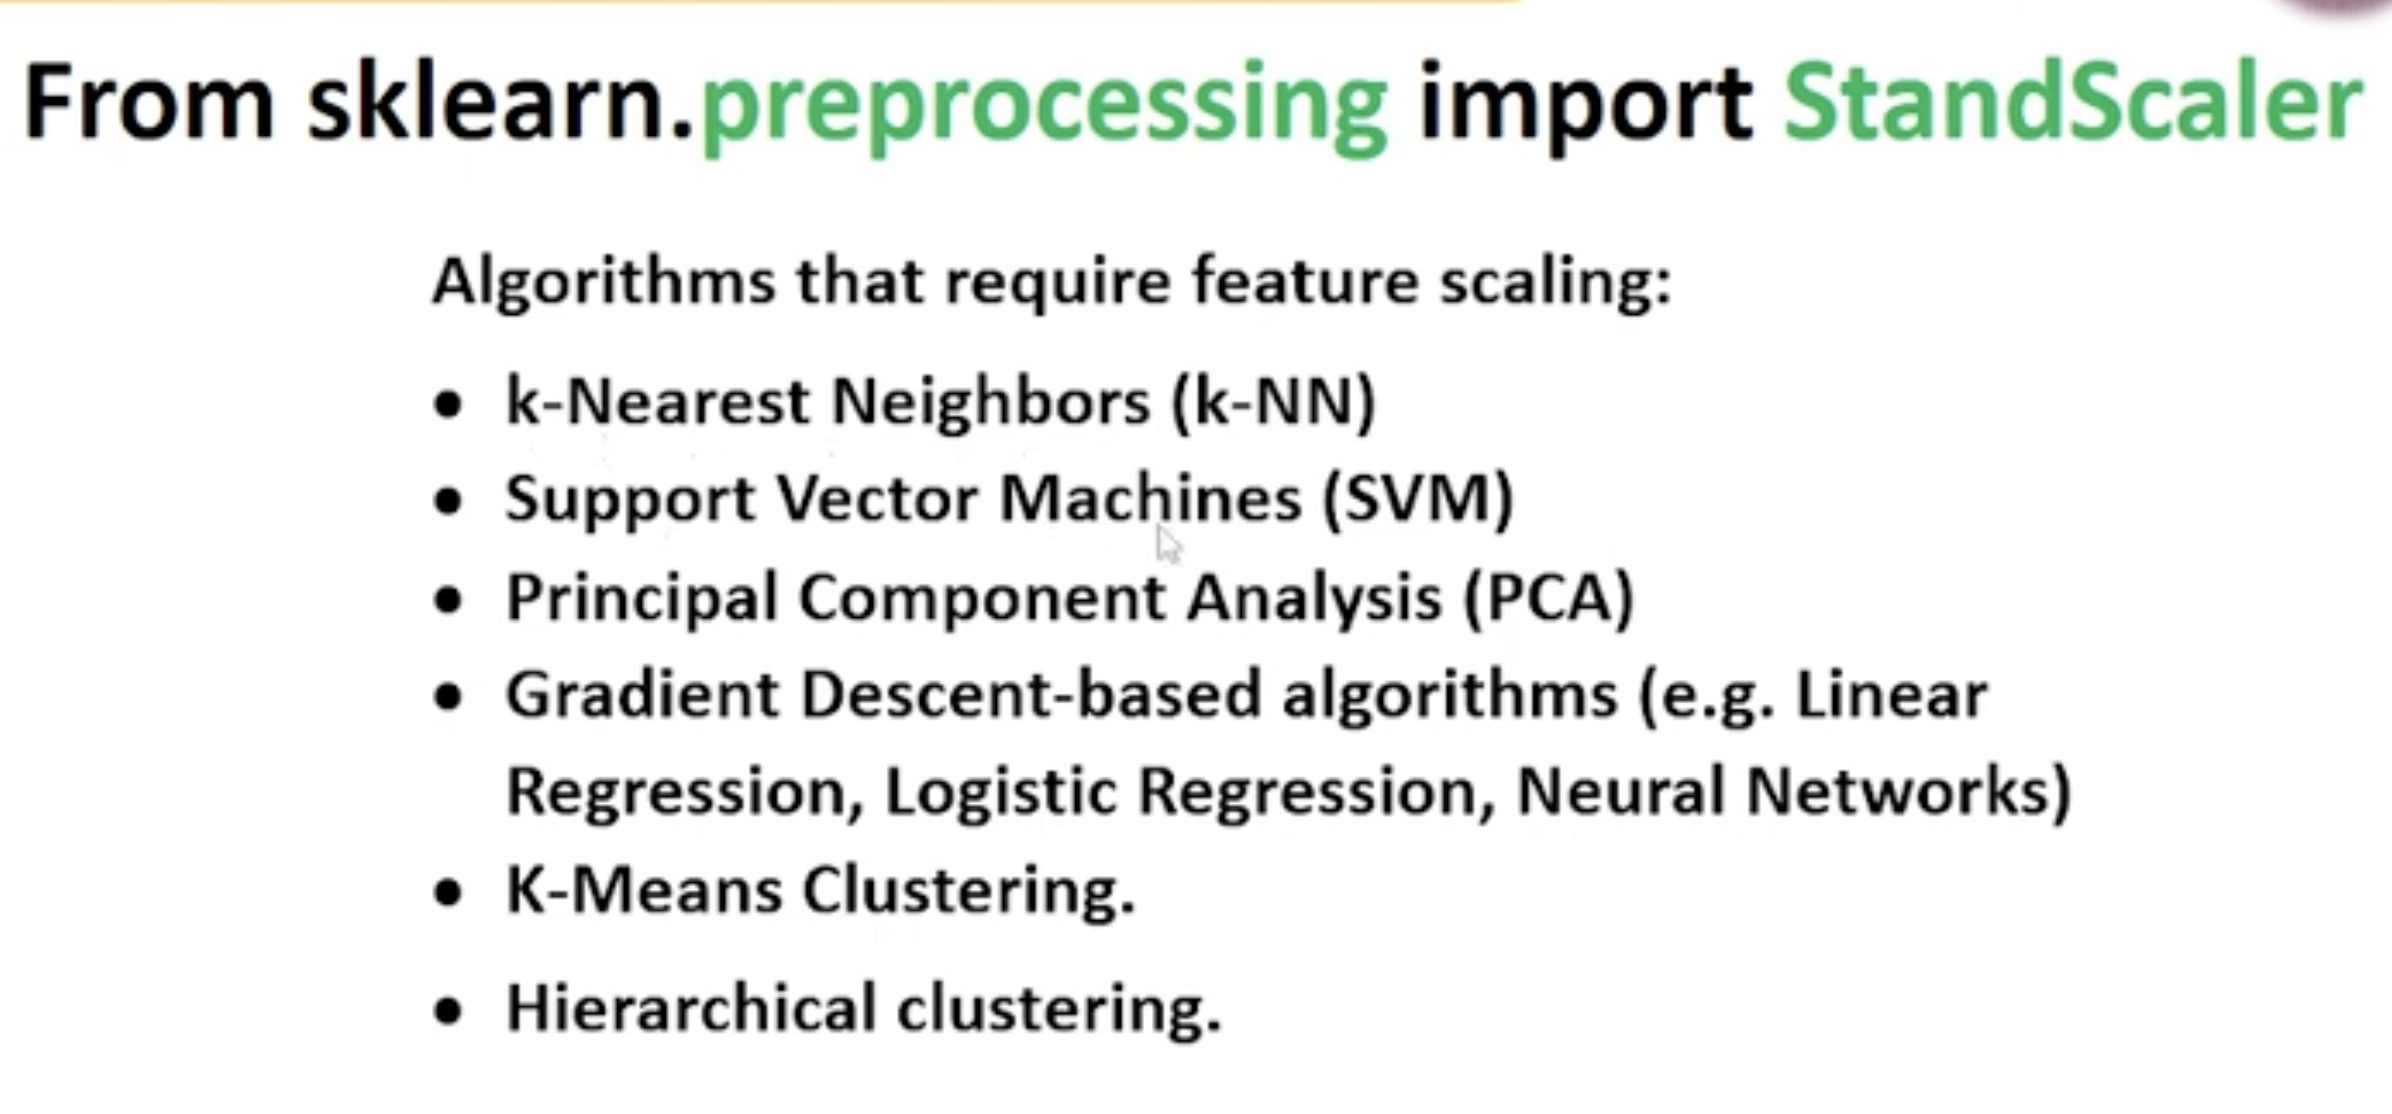

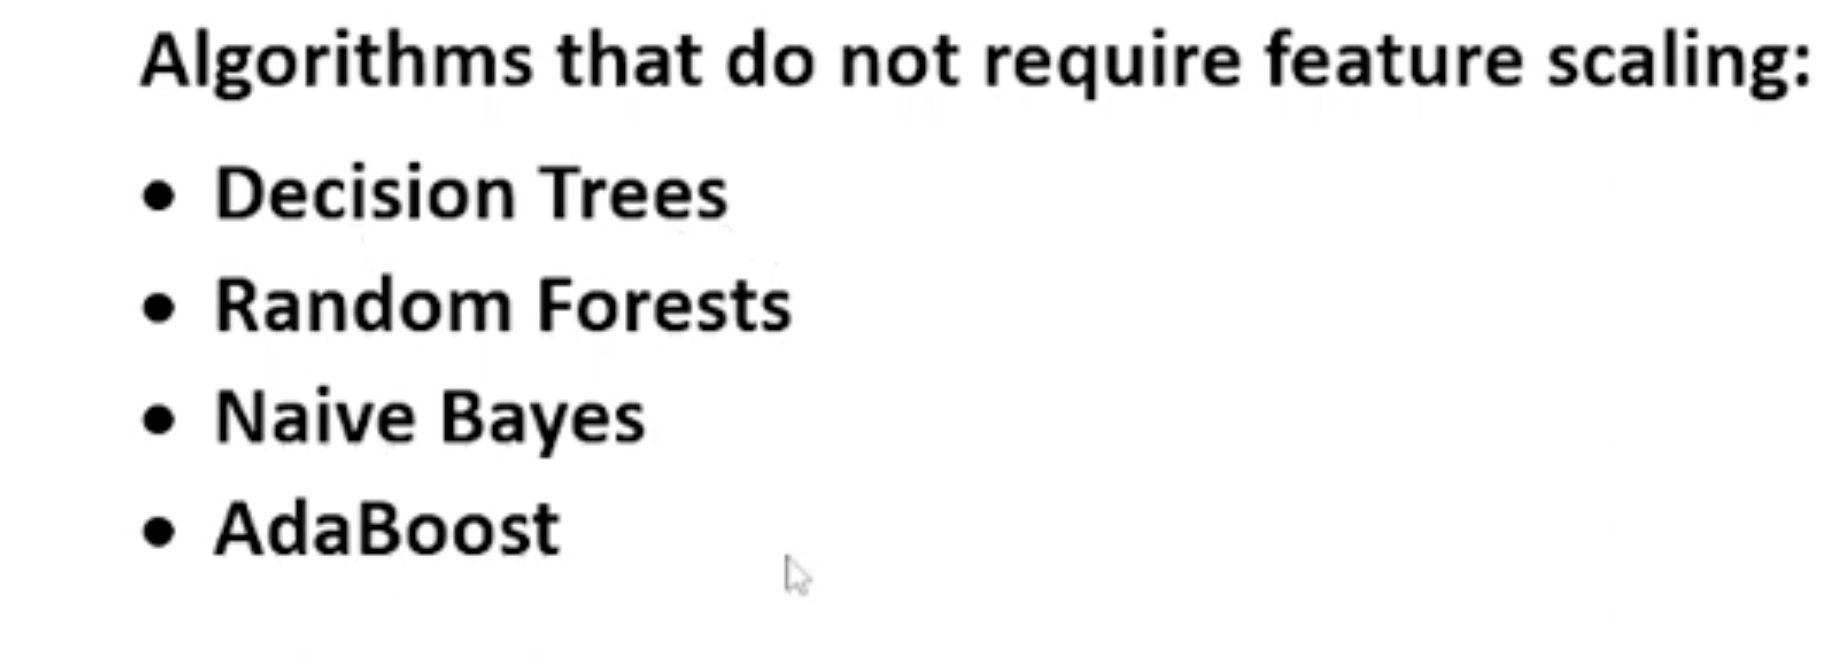

In [58]:
# scaler.fit(df)

# Learns:

# mean_
# scale_
# var_
# n_features_in_

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [68]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_train.columns)
np.round(X_train_scaled.describe(),2)

,Age,Salary,Experience
count,4.00,4.00,4.00
mean,0.00,-0.00,-0.00
std,1.15,1.15,1.15
min,-1.52,-1.21,-1.22
25%,-0.51,-0.68,-0.64
50%,0.17,-0.14,-0.15
75%,0.68,0.53,0.49
max,1.18,1.50,1.51


In [70]:
X_train_scaled

,Age,Salary,Experience
0,1.183216,1.496188,1.514449
1,-0.169031,-0.498729,-0.439679
2,-1.521278,-1.211200,-1.221330
3,0.507093,0.213741,0.146560


In [69]:
scaler.mean_

array([3.125e+01, 6.750e+04, 7.250e+00])

In [71]:
scaler.var_

array([5.46875e+01, 1.23125e+09, 2.61875e+01])

In [72]:
scaler.scale_

array([7.39509973e+00, 3.50891721e+04, 5.11737237e+00])

In [73]:
scaler.n_features_in_

3

## Applying Robust Scaler

In [74]:
# Xnew=(X - median)/IQR
# where IQR = Q3 - Q1


## Example Dataset
import pandas as pd

outlier_df = pd.DataFrame({
    "Salary":[25000,30000,35000,40000,5000000]
})

## mean shifts heavily bcz of outlier

In [ ]:
# Attributes
# scaler.center_
# scaler.scale_

In [75]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
outlier_df=scaler.fit_transform(outlier_df)

outlier_df

array([[ -1. ],
       [ -0.5],
       [  0. ],
       [  0.5],
       [496.5]])

In [76]:
scaler.center_

array([35000.])

## Interview Question
Why is RobustScaler robust?

Because median and IQR are resistant to extreme values.

## Applying MaxAbsScaler

In [78]:
# Formula: X / max(abs(X))

# Range: -1 to 1

In [80]:
from sklearn.preprocessing import MaxAbsScaler
scaler=MaxAbsScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_train_scaled

array([[1.        , 1.        , 1.        ],
       [0.75      , 0.41666667, 0.33333333],
       [0.5       , 0.20833333, 0.06666667],
       [0.875     , 0.625     , 0.53333333]])

Best Use Case is in Sparse matrices.

Especially:

1-NLP

2-TF-IDF

3-Bag of Words

## Applying Normalizer

In [83]:
## Unlike previous scalers, this works row-wise.

# Example row: [3,4]

# Norm: sqrt(3²+4²)=5

# Output: [0.6,0.8]


## formula: x / sqrt(sum(x²))

In [89]:
from sklearn.preprocessing import Normalizer

X = [[3,4]]

normalizer = Normalizer()

print(normalizer.fit_transform(X))


[[0.6 0.8]]


In [ ]:
# Best For
# Text Classification
# Cosine Similarity
# TF-IDF vectors

## Interview Question
Why Normalizer in NLP?

Because cosine similarity depends on vector direction rather than magnitude.

## 2. Encoding Methods

Used for categorical variables.

1-LabelEncoder

2-OrdinalEncoder

3-OneHotEncoder

4-LabelBinarizer

5-MultiLabelBinarizer

6-KBinsDiscretizer

7-Binarizer

## types of categorical data -> nominal, ordinal data

nominal -> there is no order ex-Orange,Red,Yellow

ordinal -> there is order ex-Small,medium,large,extra large

## Encoding using only pandas

In [106]:
df=pd.read_csv('/Users/priyanshugupta/Desktop/scikit learn/CAR DETAILS FROM CAR DEKHO.csv',usecols=['name','seller_type','transmission','owner','fuel'])
df.drop('name',axis=1,inplace=True)

In [107]:
print(df['transmission'].value_counts())
print(df['seller_type'].value_counts())

transmission
Manual       3892
Automatic     448
Name: count, dtype: int64
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64


In [108]:
## without label encoder
df['transmission']=df['transmission'].map({'Manual':0,'Automatic':1})
df['seller_type']=df['seller_type'].map({'Individual':0,'Dealer':1,'Trustmark Dealer':2})


In [110]:
df.sample(5)

,fuel,seller_type,transmission,owner
172,Diesel,0,0,Second Owner
4312,Diesel,0,0,First Owner
446,Petrol,0,0,Second Owner
2492,Diesel,0,0,First Owner
1383,Diesel,0,0,Second Owner


In [135]:
df=pd.read_csv('/Users/priyanshugupta/Desktop/scikit learn/CAR DETAILS FROM CAR DEKHO.csv',usecols=['name','seller_type','transmission','owner','fuel'])
X_train,X_test,y_train,y_test=train_test_split(df.drop('fuel',axis=1),df['fuel'],test_size=0.2,random_state=42)
X_train

,name,seller_type,transmission,owner
227,Mahindra Scorpio S11 BSIV,Individual,Manual,First Owner
964,Maruti Swift Dzire VDI,Individual,Manual,First Owner
2045,Maruti Alto 800 LXI,Individual,Manual,Second Owner
1025,Chevrolet Beat Diesel LS,Individual,Manual,First Owner
4242,Maruti Vitara Brezza LDi Option,Dealer,Manual,First Owner
...,...,...,...,...
3444,Toyota Innova 2.5 G (Diesel) 8 Seater BS IV,Individual,Manual,First Owner
466,Tata Indica Vista Quadrajet LX,Individual,Manual,First Owner
3092,Maruti Ciaz VDi Plus SHVS,Dealer,Manual,First Owner
3772,Maruti Ertiga VDI,Individual,Manual,First Owner


In [136]:
y_train.value_counts()

fuel
Diesel      1714
Petrol      1704
CNG           35
LPG           18
Electric       1
Name: count, dtype: int64

## Label Encoder

Label Encoder is used for the y part always


In [137]:
from sklearn.preprocessing import LabelEncoder 
le=LabelEncoder()
encoded=le.fit_transform(y_train)
np.unique(encoded)

array([0, 1, 2, 3, 4])

## Attributes

le.classes_

In [138]:
le.classes_

array(['CNG', 'Diesel', 'Electric', 'LPG', 'Petrol'], dtype=object)

## Reverse Transformation

In [139]:
le.inverse_transform(encoded)

array(['Diesel', 'Diesel', 'Petrol', ..., 'Diesel', 'Diesel', 'Petrol'],
      shape=(3472,), dtype=object)

In [140]:
## to know the relationship between encoded values and labels
le.inverse_transform([0,1,2,3,4])

array(['CNG', 'Diesel', 'Electric', 'LPG', 'Petrol'], dtype=object)

In [ ]:
y_test=le.transform(y_test)
y_train=encoded

In [143]:
y_train

array([1, 1, 4, ..., 1, 1, 4], shape=(3472,))

In [144]:
y_test

array([1, 4, 4, 1, 1, 4, 4, 4, 1, 4, 1, 1, 1, 1, 4, 4, 1, 1, 4, 1, 1, 1,
       4, 1, 1, 1, 1, 4, 4, 4, 4, 4, 1, 1, 4, 1, 1, 4, 4, 4, 1, 4, 1, 1,
       1, 1, 4, 1, 1, 1, 1, 4, 4, 4, 4, 1, 1, 1, 4, 4, 4, 1, 4, 1, 4, 4,
       4, 4, 1, 1, 1, 4, 4, 1, 1, 1, 1, 1, 4, 1, 1, 4, 4, 4, 4, 1, 1, 4,
       4, 4, 4, 4, 4, 4, 4, 1, 1, 1, 4, 1, 4, 1, 1, 4, 1, 1, 4, 1, 4, 1,
       3, 4, 1, 4, 4, 1, 3, 4, 1, 1, 1, 1, 1, 1, 1, 4, 4, 1, 4, 4, 1, 1,
       1, 4, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 1, 4, 1, 1, 1, 1, 4, 0, 1, 4,
       1, 4, 1, 4, 4, 1, 1, 1, 1, 4, 4, 1, 1, 1, 4, 4, 1, 4, 4, 4, 1, 1,
       4, 1, 4, 1, 1, 1, 1, 4, 4, 1, 4, 1, 4, 1, 1, 4, 1, 4, 4, 4, 1, 4,
       1, 4, 4, 1, 1, 1, 4, 1, 4, 4, 4, 1, 4, 1, 1, 4, 4, 4, 4, 1, 4, 4,
       1, 4, 4, 4, 1, 1, 1, 1, 1, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1, 1, 1, 4,
       1, 4, 4, 1, 1, 4, 1, 4, 4, 1, 4, 4, 1, 4, 1, 4, 4, 4, 1, 4, 4, 4,
       1, 1, 1, 4, 4, 4, 1, 1, 4, 4, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 4, 4,
       1, 1, 4, 4, 4, 4, 4, 4, 4, 1, 4, 4, 4, 1, 1,

## Interview Question

Why shouldn't LabelEncoder be used on input features?

Because it creates false ordering.

Example:

Red=0,Blue=1,Green=2

Model assumes:

Green > Blue > Red

## OrdinalEncoder

Used only when categories have order.

Example:

Small < Medium < Large

In [154]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder(categories=[['First Owner','Second Owner','Third Owner','Fourth & Above Owner','Test Drive Car']]) ## you mention the order here 

X_train['owner'].value_counts()
## owner is ordinal categorical variable

owner
First Owner             2262
Second Owner             878
Third Owner              245
Fourth & Above Owner      72
Test Drive Car            15
Name: count, dtype: int64

In [155]:
X_train['owner']=oe.fit_transform(X_train[['owner']])
X_test['owner']=oe.transform(X_test[['owner']])
X_train['owner'].value_counts()

owner
0.0    2262
1.0     878
2.0     245
3.0      72
4.0      15
Name: count, dtype: int64

In [160]:
oe.inverse_transform([[0.0],[1.0],[2.0],[3.0],[4.0]])

array([['First Owner'],
       ['Second Owner'],
       ['Third Owner'],
       ['Fourth & Above Owner'],
       ['Test Drive Car']], dtype=object)

In [162]:
X_train.drop('name',axis=1,inplace=True)
X_test.drop('name',axis=1,inplace=True)

In [163]:
X_train

,seller_type,transmission,owner
227,Individual,Manual,0.0
964,Individual,Manual,0.0
2045,Individual,Manual,1.0
1025,Individual,Manual,0.0
4242,Dealer,Manual,0.0
...,...,...,...
3444,Individual,Manual,0.0
466,Individual,Manual,0.0
3092,Dealer,Manual,0.0
3772,Individual,Manual,0.0


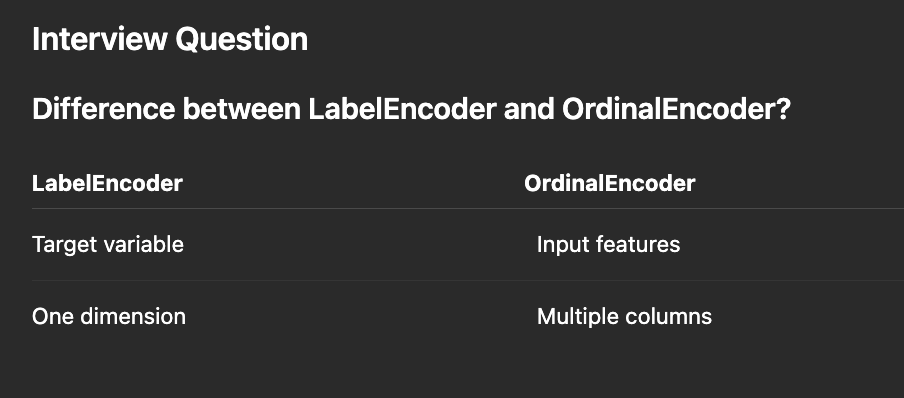

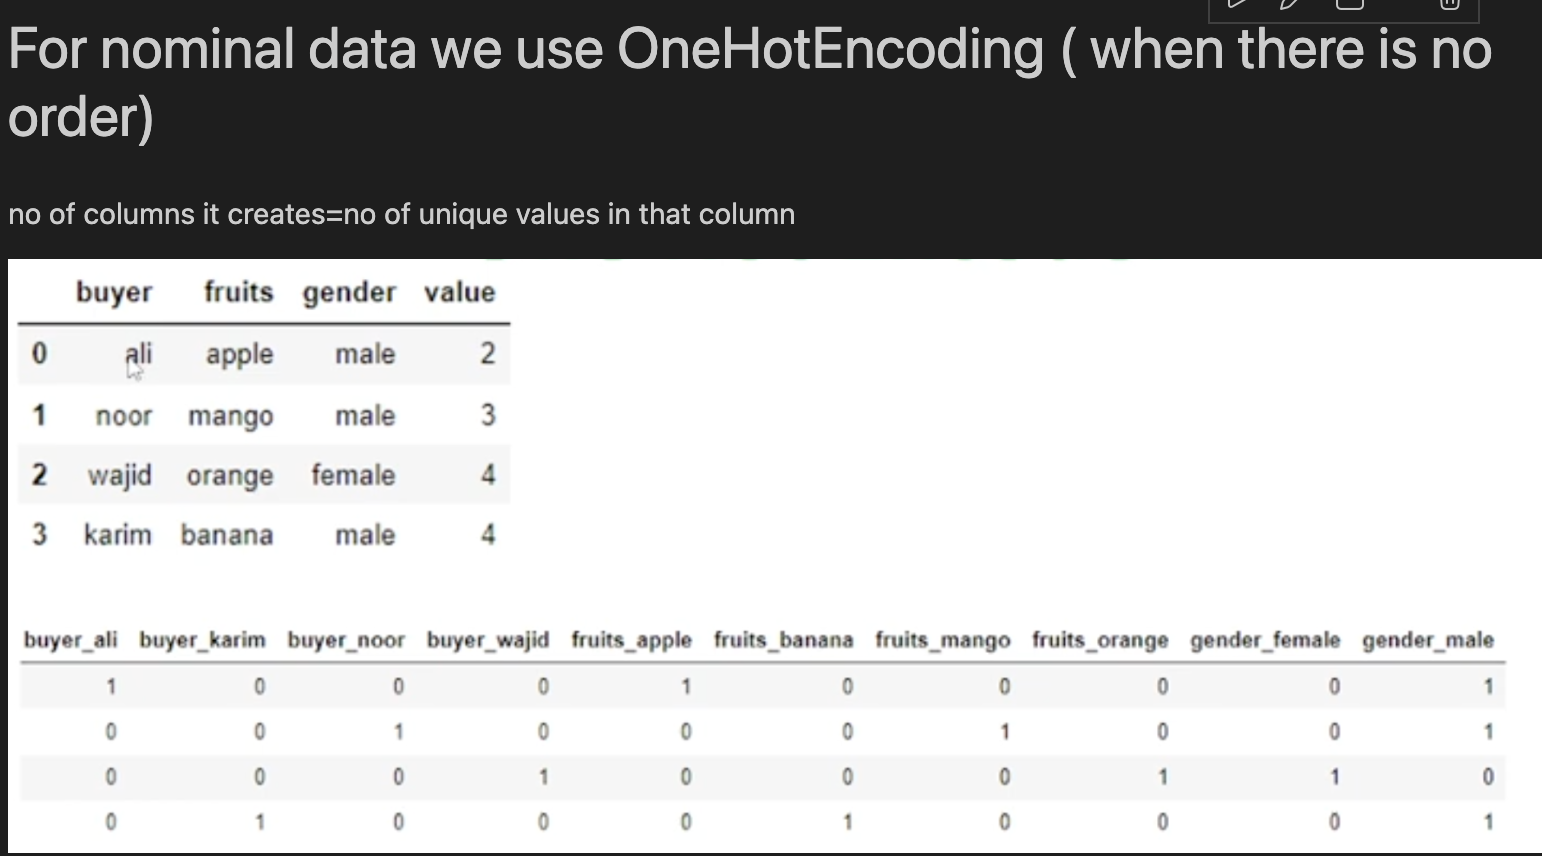

In [165]:
## using pandas only
df.drop('name',inplace=True,axis=1)

In [169]:
pd.get_dummies(df,columns=['owner','fuel'],dtype=int)

,seller_type,transmission,owner_0.0,owner_1.0,owner_2.0,owner_3.0,owner_4.0,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol
0,Individual,Manual,1,0,0,0,0,0,0,0,0,1
1,Individual,Manual,1,0,0,0,0,0,0,0,0,1
2,Individual,Manual,1,0,0,0,0,0,1,0,0,0
3,Individual,Manual,1,0,0,0,0,0,0,0,0,1
4,Individual,Manual,0,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4335,Individual,Manual,0,1,0,0,0,0,1,0,0,0
4336,Individual,Manual,0,1,0,0,0,0,1,0,0,0
4337,Individual,Manual,0,1,0,0,0,0,0,0,0,1
4338,Individual,Manual,1,0,0,0,0,0,1,0,0,0


## OneHotEncoder

In [170]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder()

In [ ]:
## for a col with only two values we remove the first column bcz second col already tells about it 
## if 1st col is 0 then second col will obviously 1 and vice versa
## pd.get_dummies(data=df,columns=[], drop_first='first')

When Sparse=True, the encoded output is returned as a sparse matrix,while sparse=False returns a dense matrix

In [177]:
from sklearn.preprocessing import OneHotEncoder 
encoder = OneHotEncoder( sparse_output=False ) 
X = [["Red"],["Blue"],["Green"]]
encoded = encoder.fit_transform(X) 
print(encoded)

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


In [179]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(sparse_output=True)
X = [["Red"],["Blue"],["Green"]]
encoded = encoder.fit_transform(X) 
print(encoded)

##. (0,2) -> 1 means 0th row and 2nd col has value 1

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3 stored elements and shape (3, 3)>
  Coords	Values
  (0, 2)	1.0
  (1, 0)	1.0
  (2, 1)	1.0


In [180]:
encoder.get_feature_names_out()

array(['x0_Blue', 'x0_Green', 'x0_Red'], dtype=object)

## Drop First Category
OneHotEncoder(
    drop='first'
)

Avoids multicollinearity.

## Handle Unknown Categories
OneHotEncoder(
    handle_unknown='ignore'
)

## Interview Questions

## Q1 What is Dummy Variable Trap?

Perfect multicollinearity caused by all dummy columns existing together.

## Q2 Difference between pandas.get_dummies() and OneHotEncoder?

OneHotEncoder integrates with pipelines.

In [ ]:
from sklearn.preprocessing import OneHotEncoder


In [212]:
X_train['transmission'].value_counts()

transmission
Manual       3109
Automatic     363
Name: count, dtype: int64

In [215]:
transformed1

array([[1],
       [1],
       [1],
       ...,
       [1],
       [1],
       [1]], shape=(3472, 1))

In [216]:
X_train['seller_type'].value_counts()

seller_type
Individual          2598
Dealer               795
Trustmark Dealer      79
Name: count, dtype: int64

In [217]:
ohe=OneHotEncoder(sparse_output=False,dtype=int,handle_unknown='ignore')
transformed2=ohe.fit_transform(X_train[['seller_type']])


In [218]:
transformed2


array([[0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       ...,
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0]], shape=(3472, 3))

In [221]:
cols=ohe.get_feature_names_out()
pd.DataFrame(data=transformed2,columns=cols)

,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,1,0,0
...,...,...,...
3467,0,1,0
3468,0,1,0
3469,1,0,0
3470,0,1,0


## Binarizer

In [ ]:
from sklearn.preprocessing import Binarizer
## Converts values to 0 or 1 using threshold.

import pandas as pd

df = pd.DataFrame({
    "Age":[20,25,30,35,40],
    "Salary":[25000,35000,50000,75000,120000],
    "Experience":[1,2,5,8,15], 
    'Rich':[0,0,0,1,1]
})

## Salary <= 50000 → 0 Salary > 50000 → 1

,Age,Salary,Experience,Rich
0,20,25000,1,0
1,25,35000,2,0
2,30,50000,5,0
3,35,75000,8,1
4,40,120000,15,1


In [224]:
b=Binarizer(threshold=50000)
salary_binary=b.fit_transform(df[['Salary']])
salary_binary

array([[0],
       [0],
       [0],
       [1],
       [1]])

## LabelBinarizer

Converts labels to one-hot vectors.

In [3]:
# Difference from OneHotEncoder


# LabelBinarizer	OneHotEncoder
# Target variable	Input feature

In [1]:
from sklearn.preprocessing import LabelBinarizer
lb=LabelBinarizer()
y = ["Dog","Cat","Bird"]
encoded=lb.fit_transform(y)
encoded

array([[0, 0, 1],
       [0, 1, 0],
       [1, 0, 0]])

## MultiLabelBinarizer

Used when one sample contains multiple labels.

In [4]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb=MultiLabelBinarizer()

X = [ ["Python","ML"], ["Python","DL"], ["SQL","ML"] ]

encoded=mlb.fit_transform(X)
print(encoded)

[[0 1 1 0]
 [1 0 1 0]
 [0 1 0 1]]


In [ ]:
from sklearn.preprocessing import add_dummy_feature
# Adds a column of ones.
# Useful for bias term.
import pandas as pd
df = pd.DataFrame({ "Age":[20,25,30,35,40], "Salary":[25000,35000,50000,75000,120000], "Experience":[1,2,5,8,15] }) 
add_dummy_feature(df) ## first col is filled with one values

array([[1.0e+00, 2.0e+01, 2.5e+04, 1.0e+00],
       [1.0e+00, 2.5e+01, 3.5e+04, 2.0e+00],
       [1.0e+00, 3.0e+01, 5.0e+04, 5.0e+00],
       [1.0e+00, 3.5e+01, 7.5e+04, 8.0e+00],
       [1.0e+00, 4.0e+01, 1.2e+05, 1.5e+01]])

## KBinsDiscretizer

Converts numerical variables into categories.

In [23]:
from sklearn.preprocessing import KBinsDiscretizer

kbd=KBinsDiscretizer(
    n_bins=3,
    encode='ordinal',
    strategy='uniform' 
)

X = [[18],[25],[32],[65]]
print(kbd.fit_transform(X))

[[0.]
 [0.]
 [0.]
 [2.]]


## Strategies:

1-uniform

2-Equal width bins.

3-quantile

4-Equal number of samples.

5-kmeans

6-KMeans based bins.

## Interview Question
Why discretize continuous variables?

Some models perform better on categories and interpretability improves.